In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../dataset/online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [5]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64

In [ ]:
df.duplicated().sum()


np.int64(6865)

In [7]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [8]:
df["Country"].value_counts().head(15)

Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Sweden                902
Italy                 731
Australia             654
Cyprus                554
Austria               537
Name: count, dtype: int64

In [9]:
df["Quantity"].describe()

count    525461.000000
mean         10.337667
std         107.424110
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: Quantity, dtype: float64

In [10]:
df["Price"].describe()

count    525461.000000
mean          4.688834
std         146.126914
min      -53594.360000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64

In [14]:
df[df.duplicated()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


In [15]:
df[df.duplicated()].shape

(6865, 8)

In [16]:
df[df["Quantity"] < 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [17]:
df[df["Quantity"] < 0].shape

(12326, 8)

In [21]:
df[df["Price"] < 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [22]:
df[df["Price"] < 0].shape

(3, 8)

In [23]:
df[df["Price"] == 0].shape

(3687, 8)

In [24]:
uk_percentage = (df["Country"].value_counts()["United Kingdom"] / len(df)) * 100

uk_percentage

np.float64(92.46204761152588)

In [25]:
df[df.duplicated()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


In [26]:
df[df["Quantity"] < 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [27]:
df[df["Quantity"] < 0].shape

(12326, 8)

In [28]:
df[df["Price"] < 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [29]:
df[df["Price"] < 0].shape

(3, 8)

In [30]:
df[df["Price"] == 0].shape

(3687, 8)

In [31]:
df[df["Quantity"] > 1000].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
7302,490018,21981,PACK OF 12 WOODLAND TISSUES,4320,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
7303,490018,21967,PACK OF 12 SKULL TISSUES,5184,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
7304,490018,21984,PACK OF 12 PINK PAISLEY TISSUES,4008,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
7305,490018,21980,PACK OF 12 RED SPOTTY TISSUES,4008,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
17384,490758,72008,NaN,3000,2009-12-08 09:38:00,0.00,NaN,United Kingdom
22100,491133,16014,SMALL CHINESE STYLE SCISSOR,1500,2009-12-09 16:17:00,0.32,13848.0,United Kingdom
23689,491212,20668,DISCO BALL CHRISTMAS DECORATION,1002,2009-12-10 14:28:00,0.10,14062.0,United Kingdom
24815,491440,72756,FAIRY CAKE CANDLES,1080,2009-12-11 10:31:00,1.25,16029.0,United Kingdom
33391,492185,16014,SMALL CHINESE STYLE SCISSOR,3000,2009-12-15 15:48:00,0.32,16308.0,United Kingdom
43522,493108,47503F,NaN,2300,2009-12-22 11:23:00,0.00,NaN,United Kingdom


In [32]:
df[df["Price"] > 1000].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
9307,C490129,M,Manual,-1,2009-12-03 18:26:00,1998.49,15482.0,United Kingdom
22960,491176,M,Manual,1,2009-12-10 11:50:00,1213.02,13091.0,United Kingdom
56523,C494477,M,Manual,-1,2010-01-14 15:40:00,1747.62,NaN,United Kingdom
62735,494918,DOT,DOTCOM POSTAGE,1,2010-01-19 17:49:00,1081.70,NaN,United Kingdom
65448,C495234,M,Manual,-1,2010-01-22 09:39:00,1193.89,14156.0,EIRE
65449,495235,M,Manual,1,2010-01-22 09:40:00,1193.89,14156.0,EIRE
71077,495798,ADJUST,Adjustment by john on 26/01/2010 17,1,2010-01-26 17:25:00,5117.03,NaN,United Kingdom
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom
74357,C496116,M,Manual,-1,2010-01-29 11:05:00,8985.60,17949.0,United Kingdom
74358,C496118,M,Manual,-1,2010-01-29 11:06:00,1065.54,17940.0,United Kingdom


In [33]:
duplicate_count = df.duplicated().sum()

duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percentage)

Duplicate rows: 6865
Duplicate percentage: 1.306471840916833


In [34]:
negative_quantity_count = (df["Quantity"] < 0).sum()

print("Negative quantity rows:", negative_quantity_count)

Negative quantity rows: 12326


In [35]:
negative_quantity_percentage = (negative_quantity_count / len(df)) * 100

print("Negative quantity percentage:", negative_quantity_percentage)

Negative quantity percentage: 2.3457497321399687


In [36]:
negative_qty = df[df["Quantity"] < 0]

negative_qty["Invoice"].str.startswith("C").value_counts()

Invoice
True    10205
Name: count, dtype: int64

In [39]:
negative_non_c = df[
    (df["Quantity"] < 0) &
    (df["Invoice"].str.startswith("C") == False)
]

negative_non_c.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [40]:
negative_non_c.shape

(0, 8)

In [41]:
df["Invoice"].str.startswith("C") == False

0         False
1         False
2         False
3         False
4         False
          ...  
525456    False
525457    False
525458    False
525459    False
525460    False
Name: Invoice, Length: 525461, dtype: bool

In [42]:
df.loc[df["Quantity"] < 0, "Invoice"].str.startswith("C").value_counts()

Invoice
True    10205
Name: count, dtype: int64

In [46]:
negative_qty = df[df["Quantity"] < 0]

negative_qty[
    negative_qty["Invoice"].str.startswith("C") == False
].head(20)
negative_qty[
 negative_qty["Invoice"].str.startswith("C") == False
].shape

(0, 8)

In [47]:
df[df["Price"] < 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [48]:
df[df["Price"] < 0].shape

(3, 8)

In [49]:
df[df["Price"] == 0].shape

(3687, 8)

In [50]:
df[df["Price"] == 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [51]:
zero_price = df[df["Price"] == 0]

zero_price["Quantity"].apply(
    lambda x: "Positive" if x > 0 else "Negative" if x < 0 else "Zero"
).value_counts()

Quantity
Negative    2121
Positive    1566
Name: count, dtype: int64

In [52]:
zero_price["Description"].isnull().sum()

np.int64(2928)

In [53]:
zero_price["Customer ID"].isnull().sum()

np.int64(3656)

In [54]:
df[df["Quantity"] > 1000].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
7302,490018,21981,PACK OF 12 WOODLAND TISSUES,4320,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
7303,490018,21967,PACK OF 12 SKULL TISSUES,5184,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
7304,490018,21984,PACK OF 12 PINK PAISLEY TISSUES,4008,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
7305,490018,21980,PACK OF 12 RED SPOTTY TISSUES,4008,2009-12-03 12:31:00,0.25,17940.0,United Kingdom
17384,490758,72008,NaN,3000,2009-12-08 09:38:00,0.00,NaN,United Kingdom
22100,491133,16014,SMALL CHINESE STYLE SCISSOR,1500,2009-12-09 16:17:00,0.32,13848.0,United Kingdom
23689,491212,20668,DISCO BALL CHRISTMAS DECORATION,1002,2009-12-10 14:28:00,0.10,14062.0,United Kingdom
24815,491440,72756,FAIRY CAKE CANDLES,1080,2009-12-11 10:31:00,1.25,16029.0,United Kingdom
33391,492185,16014,SMALL CHINESE STYLE SCISSOR,3000,2009-12-15 15:48:00,0.32,16308.0,United Kingdom
43522,493108,47503F,NaN,2300,2009-12-22 11:23:00,0.00,NaN,United Kingdom


In [55]:
df[df["Quantity"] > 1000].shape

(236, 8)

In [56]:
df[df["Quantity"] < -1000].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom
7205,490016,21982,NaN,-1012,2009-12-03 12:30:00,0.00,NaN,United Kingdom
26005,491639,20668,NaN,-1395,2009-12-11 16:02:00,0.00,NaN,United Kingdom
47635,493821,17129D,missing (wrongly coded?),-2127,2010-01-07 12:43:00,0.00,NaN,United Kingdom
65138,495199,17061,NaN,-1198,2010-01-21 16:25:00,0.00,NaN,United Kingdom
65186,495210,16044,NaN,-1129,2010-01-21 16:58:00,0.00,NaN,United Kingdom
68648,495464,72024HC,NaN,-3669,2010-01-25 12:07:00,0.00,NaN,United Kingdom
93676,C498151,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,-2504,2010-02-17 10:37:00,1.45,13902.0,Denmark
95372,498394,22433,my error - connor,-4200,2010-02-18 15:10:00,0.00,NaN,United Kingdom
110887,500005,84934,missing,-1782,2010-03-04 09:49:00,0.00,NaN,United Kingdom


In [57]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Q1: 1.0
Q3: 10.0
IQR: 9.0
Lower limit: -12.5
Upper limit: 23.5


In [58]:
quantity_outliers = df[
    (df["Quantity"] < lower_limit) |
    (df["Quantity"] > upper_limit)
]

print("Quantity outliers:", len(quantity_outliers))

Quantity outliers: 57870


In [59]:
positive_outliers = df[df["Quantity"] > upper_limit]
negative_outliers = df[df["Quantity"] < lower_limit]

print("Positive quantity outliers:", len(positive_outliers))
print("Negative quantity outliers:", len(negative_outliers))

Positive quantity outliers: 55395
Negative quantity outliers: 2475


In [60]:
Q1_price = df["Price"].quantile(0.25)
Q3_price = df["Price"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price_limit = Q1_price - 1.5 * IQR_price
upper_price_limit = Q3_price + 1.5 * IQR_price

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower limit:", lower_price_limit)
print("Upper limit:", upper_price_limit)

Q1: 1.25
Q3: 4.21
IQR: 2.96
Lower limit: -3.1899999999999995
Upper limit: 8.649999999999999


In [61]:
price_outliers = df[
    (df["Price"] < lower_price_limit) |
    (df["Price"] > upper_price_limit)
]

print("Price outliers:", len(price_outliers))

Price outliers: 35273


In [62]:
df[df["Price"] > 100].head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.0,Belgium
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
5063,489856,DOT,DOTCOM POSTAGE,1,2009-12-02 14:36:00,470.24,NaN,United Kingdom
5407,489857,DOT,DOTCOM POSTAGE,1,2009-12-02 14:43:00,775.24,NaN,United Kingdom
8374,490074,DOT,DOTCOM POSTAGE,1,2009-12-03 14:39:00,862.67,NaN,United Kingdom
9307,C490129,M,Manual,-1,2009-12-03 18:26:00,1998.49,15482.0,United Kingdom
9701,490149,DOT,DOTCOM POSTAGE,1,2009-12-04 09:43:00,922.05,NaN,United Kingdom
16427,490741,DOT,DOTCOM POSTAGE,1,2009-12-07 17:56:00,862.38,NaN,United Kingdom
17266,490745,DOT,DOTCOM POSTAGE,1,2009-12-07 18:02:00,630.36,NaN,United Kingdom


In [63]:
df[df["Price"] > 100].shape

(910, 8)

In [64]:
df.nlargest(20, "Price")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
241824,C512770,M,Manual,-1,2010-06-17 16:52:00,25111.09,17399.0,United Kingdom
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom
320581,C520667,BANK CHARGES,Bank Charges,-1,2010-08-27 13:42:00,18910.69,NaN,United Kingdom
517953,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom
519294,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom
519170,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom
135012,C502262,M,Manual,-1,2010-03-23 15:20:00,10953.50,12918.0,United Kingdom
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom
135014,C502264,M,Manual,-1,2010-03-23 15:24:00,10953.50,12918.0,United Kingdom


In [65]:
df["Description"].value_counts().head(30)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3549
REGENCY CAKESTAND 3 TIER              2212
STRAWBERRY CERAMIC TRINKET BOX        1843
PACK OF 72 RETRO SPOT CAKE CASES      1466
ASSORTED COLOUR BIRD ORNAMENT         1457
60 TEATIME FAIRY CAKE CASES           1400
HOME BUILDING BLOCK WORD              1386
JUMBO BAG RED RETROSPOT               1310
LUNCH BAG RED SPOTTY                  1274
REX CASH+CARRY JUMBO SHOPPER          1232
JUMBO STORAGE BAG SUKI                1220
PACK OF 60 PINK PAISLEY CAKE CASES    1196
WOODEN FRAME ANTIQUE WHITE            1190
LUNCH BAG  BLACK SKULL.               1179
BAKING SET 9 PIECE RETROSPOT          1176
LUNCH BAG SUKI  DESIGN                1157
HEART OF WICKER LARGE                 1151
LOVE BUILDING BLOCK WORD              1142
RED HANGING HEART T-LIGHT HOLDER      1129
SWEETHEART CERAMIC TRINKET BOX        1096
JUMBO SHOPPER VINTAGE RED PAISLEY     1095
JUMBO BAG STRAWBERRY                  1091
HEART OF WICKER SMALL                 1082

In [66]:
df[df["StockCode"].isin(["POST", "DOT", "M", "BANK CHARGES", "AMAZONFEE"])][
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country"]
].head(30)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
89,489439,POST,POSTAGE,3,18.00,12682.0,France
126,489444,POST,POSTAGE,1,141.00,12636.0,USA
173,489447,POST,POSTAGE,1,130.00,12362.0,Belgium
625,489526,POST,POSTAGE,6,18.00,12533.0,Germany
927,C489538,POST,POSTAGE,-1,9.58,15796.0,United Kingdom
1244,489557,POST,POSTAGE,4,18.00,12490.0,France
2379,489597,DOT,DOTCOM POSTAGE,1,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,59.35,NaN,United Kingdom


In [67]:
df[df["Price"] > 1000][
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country"]
].head(30)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
9307,C490129,M,Manual,-1,1998.49,15482.0,United Kingdom
22960,491176,M,Manual,1,1213.02,13091.0,United Kingdom
56523,C494477,M,Manual,-1,1747.62,NaN,United Kingdom
62735,494918,DOT,DOTCOM POSTAGE,1,1081.70,NaN,United Kingdom
65448,C495234,M,Manual,-1,1193.89,14156.0,EIRE
65449,495235,M,Manual,1,1193.89,14156.0,EIRE
71077,495798,ADJUST,Adjustment by john on 26/01/2010 17,1,5117.03,NaN,United Kingdom
74356,496115,M,Manual,1,8985.60,17949.0,United Kingdom
74357,C496116,M,Manual,-1,8985.60,17949.0,United Kingdom
74358,C496118,M,Manual,-1,1065.54,17940.0,United Kingdom


In [68]:
non_product_codes = [
    "POST",
    "DOT",
    "M",
    "BANK CHARGES",
    "AMAZONFEE",
    "ADJUST"
]

non_product_rows = df[df["StockCode"].isin(non_product_codes)]

print("Non-product rows:", len(non_product_rows))
print("Percentage:", len(non_product_rows) / len(df) * 100)

Non-product rows: 2592
Percentage: 0.493281137896057


In [69]:
non_product_rows["Description"].value_counts()

Description
POSTAGE                                862
Manual                                 850
DOTCOM POSTAGE                         735
Bank Charges                            59
Adjustment by john on 26/01/2010 16     38
Adjustment by john on 26/01/2010 17     26
AMAZON FEE                               9
 Bank Charges                            6
Adjustment by Peter on 24/05/2010 1      3
Name: count, dtype: int64

In [70]:
non_product_rows.groupby("Description")["Price"].agg(
    ["count", "min", "max"]
)

,count,min,max
Description,,,
Bank Charges,6,15.00,848.43
AMAZON FEE,9,1.00,13541.33
Adjustment by Peter on 24/05/2010 1,3,72.45,358.47
Adjustment by john on 26/01/2010 16,38,4.57,342.80
Adjustment by john on 26/01/2010 17,26,10.51,5117.03
Bank Charges,59,0.96,18910.69
DOTCOM POSTAGE,735,0.00,1081.70
Manual,850,0.00,25111.09
POSTAGE,862,0.50,850.00


In [71]:
cleaned_df = df.copy()

print("Original rows:", len(df))
print("Cleaned dataset rows:", len(cleaned_df))

Original rows: 525461
Cleaned dataset rows: 525461


In [72]:
cleaned_df = cleaned_df.drop_duplicates()

print("Rows after removing duplicates:", len(cleaned_df))

Rows after removing duplicates: 518596


In [73]:
print("Remaining duplicates:", cleaned_df.duplicated().sum())

Remaining duplicates: 0


In [74]:
cleaned_df = cleaned_df[cleaned_df["Price"] >= 0]

print("Rows after removing negative prices:", len(cleaned_df))

Rows after removing negative prices: 518593


In [75]:
print("Negative prices remaining:", (cleaned_df["Price"] < 0).sum())

Negative prices remaining: 0


In [76]:

cleaned_df = df.copy()

print("Original rows:", len(df))
print("Cleaned dataset rows:", len(cleaned_df))

Original rows: 525461
Cleaned dataset rows: 525461


In [77]:
cleaned_df = cleaned_df.drop_duplicates()

print("Rows after removing duplicates:", len(cleaned_df))
print("Remaining duplicates:", cleaned_df.duplicated().sum())

Rows after removing duplicates: 518596
Remaining duplicates: 0


In [78]:
cleaned_df = cleaned_df[cleaned_df["Price"] >= 0]

print("Rows after removing negative prices:", len(cleaned_df))
print("Negative prices remaining:", (cleaned_df["Price"] < 0).sum())

Rows after removing negative prices: 518593
Negative prices remaining: 0


In [79]:
print("Missing values:")
print(cleaned_df.isnull().sum())

Missing values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107830
Country             0
dtype: int64


In [80]:
missing_description = cleaned_df[cleaned_df["Description"].isnull()]

print("Rows with missing Description:", len(missing_description))

Rows with missing Description: 2928


In [81]:
missing_description[[
    "Invoice",
    "StockCode",
    "Quantity",
    "Price",
    "Customer ID",
    "Country"
]].head(20)

,Invoice,StockCode,Quantity,Price,Customer ID,Country
470,489521,21646,-50,0.0,NaN,United Kingdom
3114,489655,20683,-44,0.0,NaN,United Kingdom
3161,489659,21350,230,0.0,NaN,United Kingdom
3731,489781,84292,17,0.0,NaN,United Kingdom
4296,489806,18010,-770,0.0,NaN,United Kingdom
4566,489821,85049G,-240,0.0,NaN,United Kingdom
6378,489882,35751C,12,0.0,NaN,United Kingdom
6555,489898,79323G,954,0.0,NaN,United Kingdom
6576,489901,21098,-200,0.0,NaN,United Kingdom
6581,489903,21166,48,0.0,NaN,United Kingdom


In [82]:
missing_description["StockCode"].value_counts().head(20)

StockCode
22950     10
84990      9
22139      8
79321      7
21768      7
84795D     7
37446      6
21478      6
72803B     6
21340      6
35970      6
84845C     6
20747      6
84467      6
37461      6
22528      6
22087      6
21490      5
84922      5
90002A     5
Name: count, dtype: int64

In [83]:
missing_customer = cleaned_df[cleaned_df["Customer ID"].isnull()]

print("Rows with missing Customer ID:", len(missing_customer))
print("Percentage:", len(missing_customer) / len(cleaned_df) * 100)

Rows with missing Customer ID: 107830
Percentage: 20.792798977232625


In [84]:
missing_customer[[
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "Country"
]].head(20)

,Invoice,StockCode,Description,Quantity,Price,Country
263,489464,21733,85123a mixed,-96,0.00,United Kingdom
283,489463,71477,short,-240,0.00,United Kingdom
284,489467,85123A,21733 mixed,-192,0.00,United Kingdom
470,489521,21646,NaN,-50,0.00,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,0.55,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,0.85,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2.95,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,1.25,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2.95,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,1.65,United Kingdom


In [85]:
cleaned_df = cleaned_df.dropna(subset=["Description"])

print("Rows after removing missing descriptions:", len(cleaned_df))
print("Missing descriptions remaining:", cleaned_df["Description"].isnull().sum())

Rows after removing missing descriptions: 515665
Missing descriptions remaining: 0


In [86]:
cleaned_df = cleaned_df.dropna(subset=["Description"])

print("Rows after removing missing descriptions:", len(cleaned_df))
print("Missing descriptions remaining:", cleaned_df["Description"].isnull().sum())
print("Missing Customer IDs remaining:", cleaned_df["Customer ID"].isnull().sum())

Rows after removing missing descriptions: 515665
Missing descriptions remaining: 0
Missing Customer IDs remaining: 104902


In [87]:
zero_price_remaining = cleaned_df[cleaned_df["Price"] == 0]

print("Zero-price rows remaining:", len(zero_price_remaining))

Zero-price rows remaining: 753


In [88]:
zero_price_remaining[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Customer ID",
        "Country"
    ]
].head(30)

,Invoice,StockCode,Description,Quantity,Customer ID,Country
263,489464,21733,85123a mixed,-96,NaN,United Kingdom
283,489463,71477,short,-240,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,NaN,United Kingdom
3162,489660,35956,lost,-1043,NaN,United Kingdom
3168,489663,35605A,damages,-117,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,NaN,United Kingdom
4674,489825,22076,6 RIBBONS EMPIRE,12,16126.0,United Kingdom
5904,489861,DOT,DOTCOM POSTAGE,1,NaN,United Kingdom
6556,489899,79323GR,sold as gold,-954,NaN,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,15658.0,United Kingdom


In [89]:
zero_price_remaining["Description"].value_counts().head(30)

Description
?                                      45
damages                                39
damaged                                38
missing                                24
OWL DOORSTOP                            8
checked                                 8
POLYESTER FILLER PAD 45x45cm            7
PICNIC BASKET WICKER LARGE              7
FLAG OF ST GEORGE CAR FLAG              6
dotcom                                  6
given away                              6
smashed                                 5
POLYESTER FILLER PAD 40x40cm            5
SMALL POPCORN HOLDER                    5
WATERING CAN BLUE ELEPHANT              5
HEART OF WICKER SMALL                   5
ENAMEL FIRE BUCKET CREAM                5
ENAMEL WASH BOWL CREAM                  5
AIRLINE BAG VINTAGE WORLD CHAMPION      5
PICNIC BASKET WICKER SMALL              5
IVORY KITCHEN SCALES                    5
MIA                                     4
Damages                                 4
ebay sales            

In [90]:
zero_price_remaining["Quantity"].apply(
    lambda x: "Positive" if x > 0 else "Negative" if x < 0 else "Zero"
).value_counts()

Quantity
Positive    459
Negative    294
Name: count, dtype: int64

In [91]:
zero_price_remaining["Customer ID"].notnull().value_counts()

Customer ID
False    722
True      31
Name: count, dtype: int64

In [92]:
zero_price_remaining["Description"].value_counts().head(30)

Description
?                                      45
damages                                39
damaged                                38
missing                                24
OWL DOORSTOP                            8
checked                                 8
POLYESTER FILLER PAD 45x45cm            7
PICNIC BASKET WICKER LARGE              7
FLAG OF ST GEORGE CAR FLAG              6
dotcom                                  6
given away                              6
smashed                                 5
POLYESTER FILLER PAD 40x40cm            5
SMALL POPCORN HOLDER                    5
WATERING CAN BLUE ELEPHANT              5
HEART OF WICKER SMALL                   5
ENAMEL FIRE BUCKET CREAM                5
ENAMEL WASH BOWL CREAM                  5
AIRLINE BAG VINTAGE WORLD CHAMPION      5
PICNIC BASKET WICKER SMALL              5
IVORY KITCHEN SCALES                    5
MIA                                     4
Damages                                 4
ebay sales            

In [93]:
non_product_codes = [
    "POST",
    "DOT",
    "M",
    "BANK CHARGES",
    "AMAZONFEE",
    "ADJUST"
]

sales_df = cleaned_df[
    (cleaned_df["Quantity"] > 0) &
    (cleaned_df["Price"] > 0) &
    (~cleaned_df["StockCode"].isin(non_product_codes))
].copy()

print("Cleaned dataset rows:", len(cleaned_df))
print("Sales dataset rows:", len(sales_df))

Cleaned dataset rows: 515665
Sales dataset rows: 502630


In [94]:
print("Negative quantities:", (sales_df["Quantity"] < 0).sum())
print("Zero quantities:", (sales_df["Quantity"] == 0).sum())
print("Negative prices:", (sales_df["Price"] < 0).sum())
print("Zero prices:", (sales_df["Price"] == 0).sum())

Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 0


In [95]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [96]:
sales_df = sales_df.rename(columns={
    "Customer ID": "Customer_ID",
    "InvoiceDate": "Invoice_Date",
    "StockCode": "Stock_Code"
})

print(sales_df.columns)

Index(['Invoice', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date',
       'Price', 'Customer_ID', 'Country'],
      dtype='str')


In [97]:
sales_df.info()

<class 'pandas.DataFrame'>
Index: 502630 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       502630 non-null  object        
 1   Stock_Code    502630 non-null  object        
 2   Description   502630 non-null  object        
 3   Quantity      502630 non-null  int64         
 4   Invoice_Date  502630 non-null  datetime64[us]
 5   Price         502630 non-null  float64       
 6   Customer_ID   399706 non-null  float64       
 7   Country       502630 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 34.5+ MB


In [98]:
sales_df["Customer_ID"] = sales_df["Customer_ID"].astype("Int64")

In [99]:
print(sales_df.dtypes)

Invoice                 object
Stock_Code              object
Description             object
Quantity                 int64
Invoice_Date    datetime64[us]
Price                  float64
Customer_ID              Int64
Country                    str
dtype: object


In [100]:
# Convert Customer_ID to nullable integer
sales_df["Customer_ID"] = sales_df["Customer_ID"].astype("Int64")

# Create total transaction amount
sales_df["TotalAmount"] = sales_df["Quantity"] * sales_df["Price"]

# Reset index after cleaning
sales_df = sales_df.reset_index(drop=True)

# Check final structure and data types
print(sales_df.info())

# Display first 5 rows
print(sales_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 502630 entries, 0 to 502629
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       502630 non-null  object        
 1   Stock_Code    502630 non-null  object        
 2   Description   502630 non-null  object        
 3   Quantity      502630 non-null  int64         
 4   Invoice_Date  502630 non-null  datetime64[us]
 5   Price         502630 non-null  float64       
 6   Customer_ID   399706 non-null  Int64         
 7   Country       502630 non-null  str           
 8   TotalAmount   502630 non-null  float64       
dtypes: Int64(1), datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 35.0+ MB
None
  Invoice Stock_Code                          Description  Quantity  \
0  489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434     79323P                   PINK CHERRY LIGHTS        12   
2  489434     79323W  

In [101]:
# Create date/time features
sales_df["Year"] = sales_df["Invoice_Date"].dt.year
sales_df["Month"] = sales_df["Invoice_Date"].dt.month
sales_df["Day"] = sales_df["Invoice_Date"].dt.day
sales_df["Hour"] = sales_df["Invoice_Date"].dt.hour

# Final validation checks
print("Rows:", len(sales_df))
print("Columns:", len(sales_df.columns))
print("\nMissing values:")
print(sales_df.isnull().sum())

print("\nDuplicate rows:", sales_df.duplicated().sum())

print("\nNegative quantity:", (sales_df["Quantity"] < 0).sum())
print("Zero quantity:", (sales_df["Quantity"] == 0).sum())
print("Negative price:", (sales_df["Price"] < 0).sum())
print("Zero price:", (sales_df["Price"] == 0).sum())

print("\nData types:")
print(sales_df.dtypes)

print("\nSample data:")
print(sales_df.head())


Rows: 502630
Columns: 13

Missing values:
Invoice              0
Stock_Code           0
Description          0
Quantity             0
Invoice_Date         0
Price                0
Customer_ID     102924
Country              0
TotalAmount          0
Year                 0
Month                0
Day                  0
Hour                 0
dtype: int64

Duplicate rows: 0

Negative quantity: 0
Zero quantity: 0
Negative price: 0
Zero price: 0

Data types:
Invoice                 object
Stock_Code              object
Description             object
Quantity                 int64
Invoice_Date    datetime64[us]
Price                  float64
Customer_ID              Int64
Country                    str
TotalAmount            float64
Year                     int32
Month                    int32
Day                      int32
Hour                     int32
dtype: object

Sample data:
  Invoice Stock_Code                          Description  Quantity  \
0  489434      85048  15CM CHRISTMAS GLAS

In [102]:
# Final preprocessing summary and save the analysis-ready dataset

# 1. Before vs After comparison
original_rows = len(df)
cleaned_rows = len(cleaned_df)
sales_rows = len(sales_df)

print("===== BEFORE vs AFTER CLEANING =====")
print("Original rows:", original_rows)
print("Cleaned rows:", cleaned_rows)
print("Sales-analysis rows:", sales_rows)
print("Rows removed from original:", original_rows - sales_rows)
print("Percentage retained:", round((sales_rows / original_rows) * 100, 2), "%")

# 2. Final missing-value check
print("\n===== MISSING VALUES =====")
print(sales_df.isnull().sum())

# 3. Final duplicate check
print("\n===== DUPLICATES =====")
print("Duplicate rows:", sales_df.duplicated().sum())

# 4. Final validity checks
print("\n===== VALIDATION =====")
print("Negative quantity:", (sales_df["Quantity"] < 0).sum())
print("Zero quantity:", (sales_df["Quantity"] == 0).sum())
print("Negative price:", (sales_df["Price"] < 0).sum())
print("Zero price:", (sales_df["Price"] == 0).sum())
print("Negative TotalAmount:", (sales_df["TotalAmount"] < 0).sum())

# 5. Final statistics
print("\n===== SALES SUMMARY =====")
print(sales_df[["Quantity", "Price", "TotalAmount"]].describe())

# 6. Save cleaned analysis-ready dataset
sales_df.to_csv("../cleaned_data/online_retail_cleaned.csv", index=False)

print("\nCleaned dataset saved successfully.")

===== BEFORE vs AFTER CLEANING =====
Original rows: 525461
Cleaned rows: 515665
Sales-analysis rows: 502630
Rows removed from original: 22831
Percentage retained: 95.66 %

===== MISSING VALUES =====
Invoice              0
Stock_Code           0
Description          0
Quantity             0
Invoice_Date         0
Price                0
Customer_ID     102924
Country              0
TotalAmount          0
Year                 0
Month                0
Day                  0
Hour                 0
dtype: int64

===== DUPLICATES =====
Duplicate rows: 0

===== VALIDATION =====
Negative quantity: 0
Zero quantity: 0
Negative price: 0
Zero price: 0
Negative TotalAmount: 0

===== SALES SUMMARY =====
            Quantity          Price    TotalAmount
count  502630.000000  502630.000000  502630.000000
mean       11.553393       3.442955      19.524867
std        87.516879       5.210647      65.812217
min         1.000000       0.001000       0.001000
25%         1.000000       1.250000       4.200

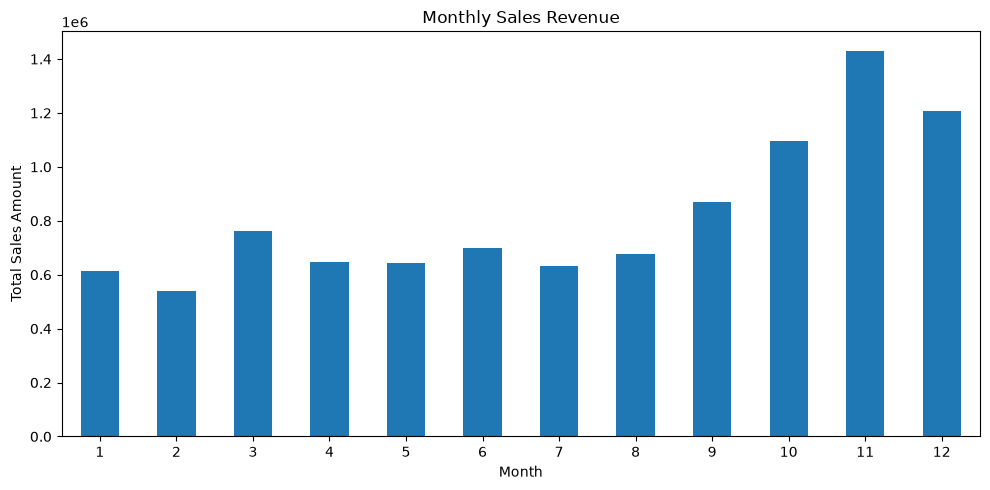

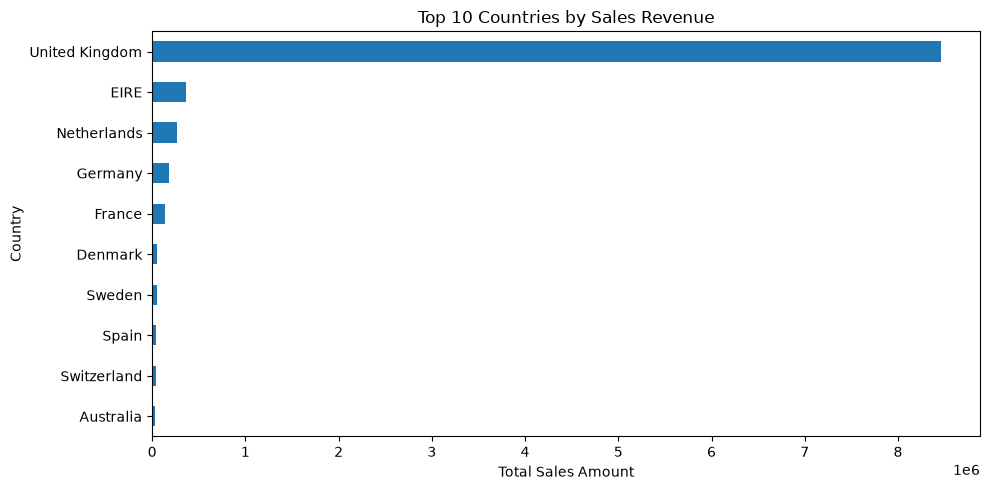

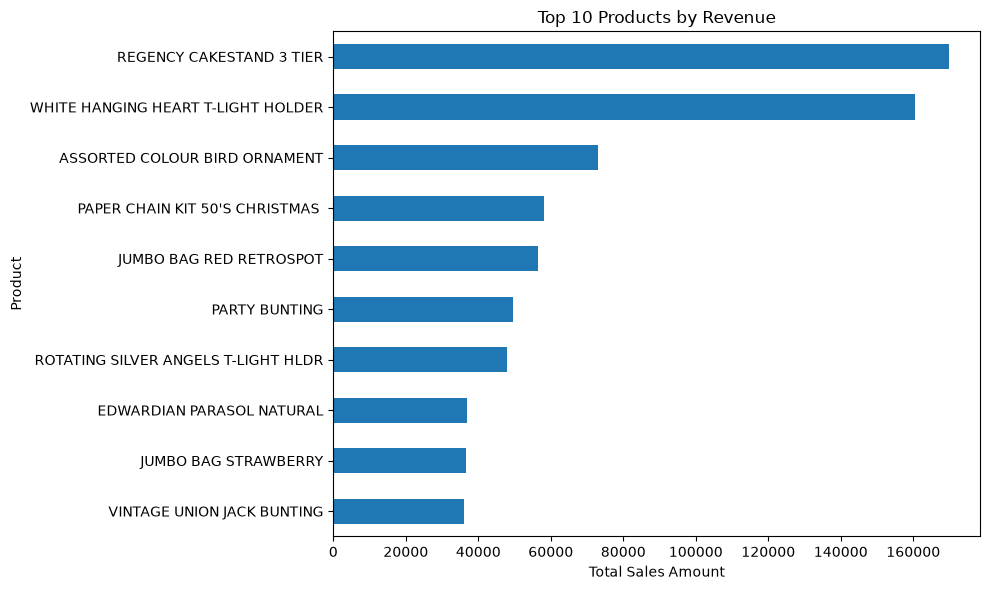

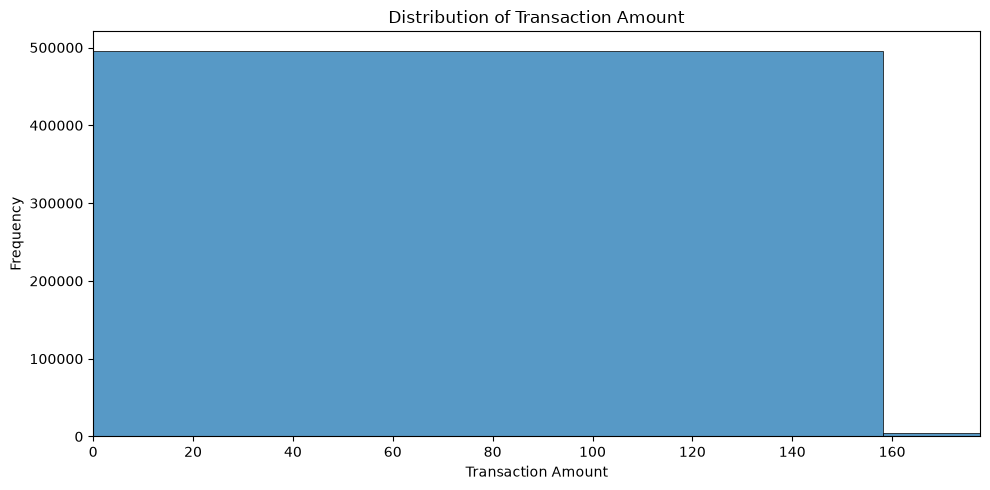

========== FINAL DATASET ==========
Rows: 502630
Columns: 13
Total Revenue: 9813783.84
Unique Products: 4245
Unique Countries: 40
Unique Customers: 4286
Date Range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00

========== FILE ==========
online_retail_cleaned.csv has already been saved.
Four charts have been saved in the screenshots folder.


In [ ]:
# FINAL EDA VISUALIZATIONS


import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create screenshots folder if it does not exist
os.makedirs("../screenshots", exist_ok=True)

# 1. Monthly Sales Revenue
monthly_sales = sales_df.groupby("Month")["TotalAmount"].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../screenshots/monthly_sales.png", dpi=300)
plt.show()


# 2. Top 10 Countries by Sales Revenue
country_sales = (
    sales_df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
country_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Sales Revenue")
plt.xlabel("Total Sales Amount")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../screenshots/top_countries_sales.png", dpi=300)
plt.show()


# 3. Top 10 Products by Revenue
product_sales = (
    sales_df.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
product_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Sales Amount")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../screenshots/top_products_revenue.png", dpi=300)
plt.show()


# 4. Total Amount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(sales_df["TotalAmount"], bins=100)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.xlim(0, sales_df["TotalAmount"].quantile(0.99))
plt.tight_layout()
plt.savefig("../screenshots/transaction_amount_distribution.png", dpi=300)
plt.show()


# FINAL DATASET SUMMARY

print("========== FINAL DATASET ==========")
print("Rows:", len(sales_df))
print("Columns:", len(sales_df.columns))
print("Total Revenue:", round(sales_df["TotalAmount"].sum(), 2))
print("Unique Products:", sales_df["Stock_Code"].nunique())
print("Unique Countries:", sales_df["Country"].nunique())
print("Unique Customers:", sales_df["Customer_ID"].nunique())
print("Date Range:", sales_df["Invoice_Date"].min(), "to", sales_df["Invoice_Date"].max())

print("\n========== FILE ==========")
print("online_retail_cleaned.csv has already been saved.")
print("Four charts have been saved in the screenshots folder.")

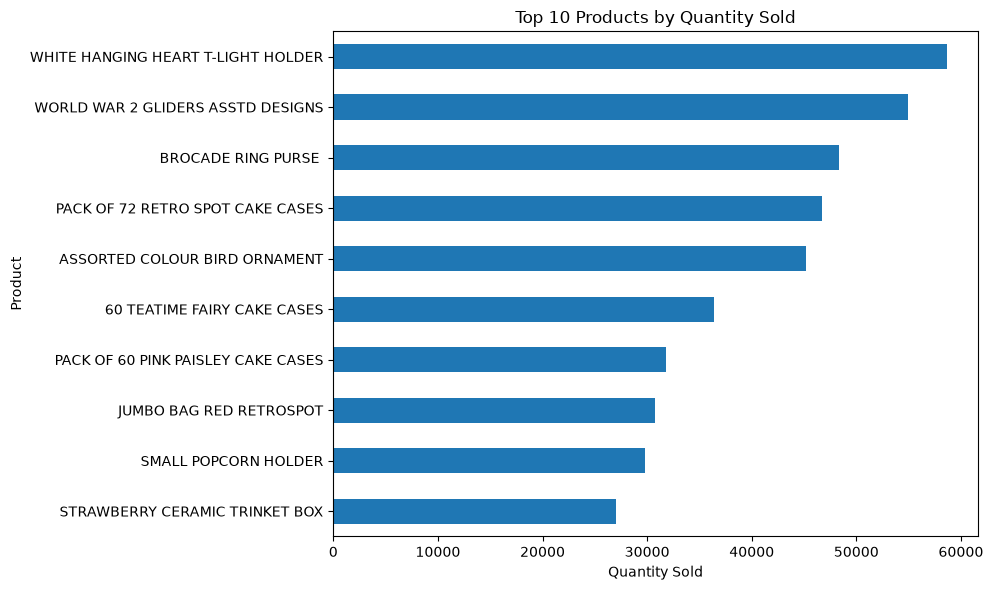

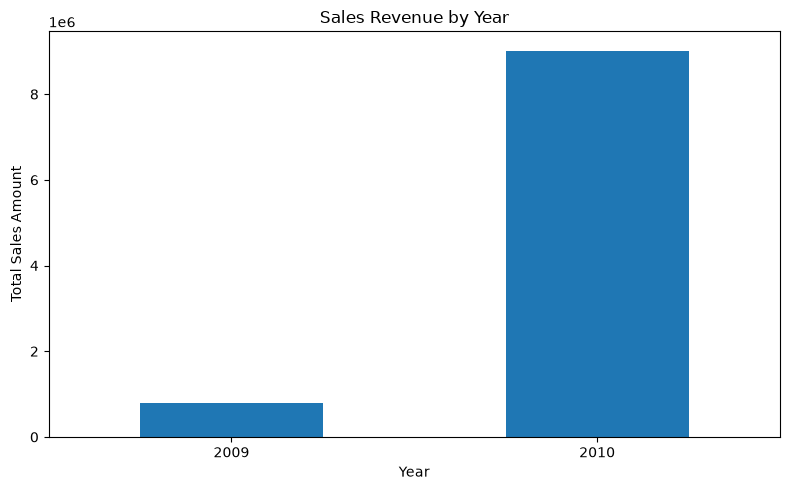

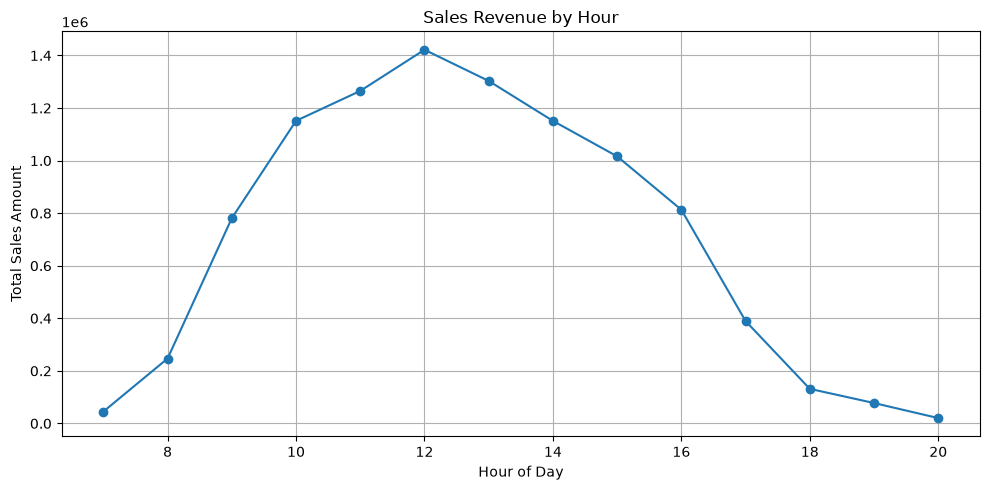

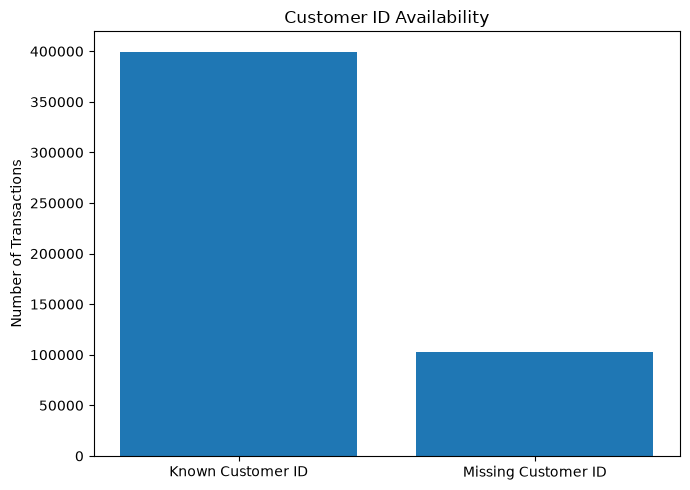

========== PROJECT STATISTICS ==========
Original rows: 525461
Cleaned rows: 515665
Sales rows: 502630
Rows removed: 22831
Data retained: 95.66 %
Total revenue: 9813783.84
Unique products: 4245
Unique customers: 4286
Unique countries: 40
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


In [104]:
# ==============================
# ADDITIONAL EDA FOR YOUR REPORT
# ==============================

# 1. Top 10 products by quantity sold
top_products_qty = (
    sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_products_qty.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../screenshots/top_products_quantity.png", dpi=300)
plt.show()


# 2. Sales by year
year_sales = sales_df.groupby("Year")["TotalAmount"].sum()

plt.figure(figsize=(8, 5))
year_sales.plot(kind="bar")
plt.title("Sales Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../screenshots/yearly_sales.png", dpi=300)
plt.show()


# 3. Sales by hour
hour_sales = sales_df.groupby("Hour")["TotalAmount"].sum()

plt.figure(figsize=(10, 5))
hour_sales.plot(kind="line", marker="o")
plt.title("Sales Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales Amount")
plt.grid(True)
plt.tight_layout()
plt.savefig("../screenshots/hourly_sales.png", dpi=300)
plt.show()


# 4. Missing Customer ID summary
known_customer = sales_df["Customer_ID"].notna().sum()
unknown_customer = sales_df["Customer_ID"].isna().sum()

plt.figure(figsize=(7, 5))
plt.bar(["Known Customer ID", "Missing Customer ID"],
        [known_customer, unknown_customer])
plt.title("Customer ID Availability")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("../screenshots/customer_id_missing.png", dpi=300)
plt.show()


# 5. Final project statistics
print("========== PROJECT STATISTICS ==========")
print("Original rows:", len(df))
print("Cleaned rows:", len(cleaned_df))
print("Sales rows:", len(sales_df))
print("Rows removed:", len(df) - len(sales_df))
print("Data retained:", round(len(sales_df) / len(df) * 100, 2), "%")
print("Total revenue:", round(sales_df["TotalAmount"].sum(), 2))
print("Unique products:", sales_df["Stock_Code"].nunique())
print("Unique customers:", sales_df["Customer_ID"].nunique())
print("Unique countries:", sales_df["Country"].nunique())
print("Date range:", sales_df["Invoice_Date"].min(), "to", sales_df["Invoice_Date"].max())

In [ ]:

# CLEANING SUMMARY TABLE FOR REPORT

cleaning_summary = pd.DataFrame({
    "Stage": [
        "Original Dataset",
        "After Removing Duplicates",
        "After Removing Negative Prices",
        "After Removing Missing Descriptions",
        "Final Sales Dataset"
    ],
    "Rows": [
        len(df),
        518596,
        518593,
        len(cleaned_df),
        len(sales_df)
    ]
})

# Calculate rows removed from previous stage
cleaning_summary["Rows Removed"] = (
    cleaning_summary["Rows"].shift(1) - cleaning_summary["Rows"]
).fillna(0).astype(int)

# Calculate percentage retained from original
cleaning_summary["Percentage Retained"] = (
    cleaning_summary["Rows"] / len(df) * 100
).round(2)

print(cleaning_summary)

# Save summary for report
cleaning_summary.to_csv(
    "../cleaned_data/cleaning_summary.csv",
    index=False
)

print("\nCleaning summary saved successfully.")

                                 Stage    Rows  Rows Removed  \
0                     Original Dataset  525461             0   
1            After Removing Duplicates  518596          6865   
2       After Removing Negative Prices  518593             3   
3  After Removing Missing Descriptions  515665          2928   
4                  Final Sales Dataset  502630         13035   

   Percentage Retained  
0               100.00  
1                98.69  
2                98.69  
3                98.14  
4                95.66  

Cleaning summary saved successfully.
